In [1]:
import os
import sys
import pysvzerod
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import savemat
import json 
from scipy.optimize import minimize, Bounds

In [2]:
os.chdir("/Users/kmbornemann/heart_valves/pressure_curves/svzerod_tune_preop")

In [3]:
MMHG_TO_CGS = 1333.22368

In [4]:
case = 'v1'

if case == 'orig':
    config = "config_preop.json"
    results = pysvzerod.simulate(config)
else:
    config = "config_preop_v1.json"
    results = pysvzerod.simulate(config)

In [5]:
df = pd.DataFrame(results)
df['pressure_in'] = df['pressure_in'] / 1333.22
df['pressure_out'] = df['pressure_out'] / 1333.22
df

,name,time,flow_in,flow_out,pressure_in,pressure_out
0,vessel_LV,0.000000,12.116266,12.116266,19.648591,1.889627e+01
1,vessel_LV,0.000822,18.158605,18.158605,18.756969,1.762947e+01
2,vessel_LV,0.001644,22.669441,22.669441,17.874462,1.646688e+01
3,vessel_LV,0.002466,24.748656,24.748656,17.009282,1.547260e+01
4,vessel_LV,0.003288,24.128480,24.128480,16.169819,1.467165e+01
...,...,...,...,...,...,...
3502,vessel_lpa,0.407712,6.923973,6.923973,45.513246,-3.193767e-18
3503,vessel_lpa,0.408534,6.904886,6.904886,45.387787,1.573667e-17
3504,vessel_lpa,0.409356,6.885733,6.885733,45.261884,4.066438e-18
3505,vessel_lpa,0.410178,6.866525,6.866525,45.135623,2.471407e-17


In [6]:
# group once, then extract arrays
groups = {name: grp for name, grp in df.groupby('name')}

# time (take from LV once)
time = np.linspace(0,0.822,2*len(groups["vessel_LV"]["time"].to_numpy()))

# flow and pressure dicts
q = {name: grp["flow_out"].to_numpy() for name, grp in groups.items()}
p = {name: grp["pressure_out"].to_numpy() for name, grp in groups.items()}

# per-vessel variables if you want them
q_lv, q_rv, q_aorta, q_rpa, q_lpa = (
    np.tile(q["vessel_LV"],2),
    np.tile(q["vessel_RV"],2),
    np.tile(q["vessel_aorta"],2),
    np.tile(q["vessel_rpa"],2),
    np.tile(q["vessel_lpa"],2),
)
p_lv, p_rv, p_aorta, p_rpa, p_lpa = (
    np.tile(p["vessel_LV"],2),
    np.tile(p["vessel_RV"],2),
    np.tile(p["vessel_aorta"],2),
    np.tile(p["vessel_rpa"],2),
    np.tile(p["vessel_lpa"],2),
)

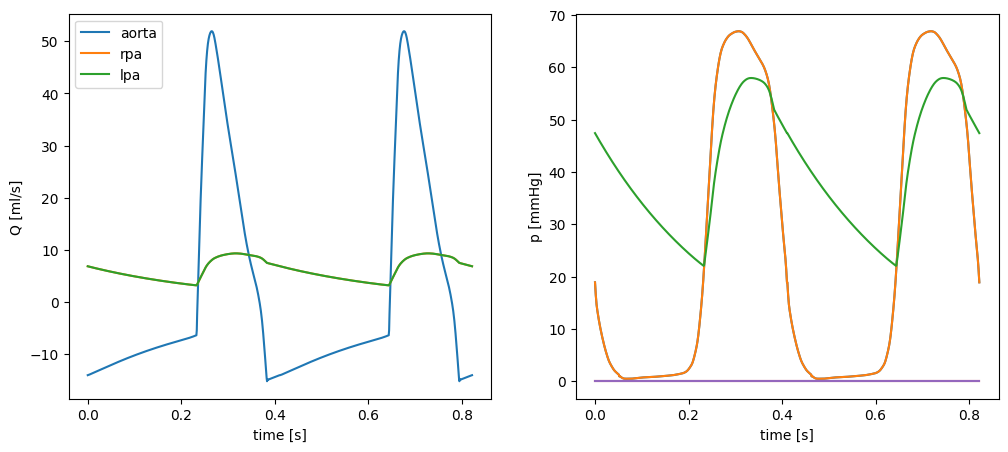

In [7]:
fig, axs = plt.subplots(1,2, figsize=(12,5))

#axs[0].plot(time,q_lv, label='LV')
#axs[0].plot(time,q_rv, label='RV')
axs[0].plot(time,q_aorta, label='aorta')
axs[0].plot(time,q_rpa, label='rpa')
axs[0].plot(time,q_lpa, label='lpa')

axs[1].plot(time,p_lv, label='LV')
axs[1].plot(time,p_rv, label='RV')
axs[1].plot(time,p_aorta, label='aorta')
axs[1].plot(time,p_rpa, label='rpa')
axs[1].plot(time,p_lpa, label='lpa')
axs[0].set_xlabel('time [s]')
axs[0].set_ylabel('Q [ml/s]')
axs[1].set_xlabel('time [s]')
axs[1].set_ylabel('p [mmHg]')
axs[0].legend()
plt.show()

In [8]:
dt = time[1]-time[0]

sv_aorta = dt * np.trapz(q_aorta[int(len(q_aorta)/2):-1])
sv_rpa = dt * np.trapz(q_rpa[int(len(q_rpa)/2):-1])
sv_lpa = dt * np.trapz(q_lpa[int(len(q_lpa)/2):-1])

QPQS = (sv_rpa+sv_lpa)/sv_aorta

print(sv_aorta)
print(sv_rpa)
print(sv_lpa)
print(QPQS)

0.8231309227129867
2.5395913018181138
2.5395913018181138
6.170564685986486


/var/folders/53/9pp819tj501d6yqpmhtbjgzm0000gn/T/ipykernel_7663/1421358536.py:3: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  sv_aorta = dt * np.trapz(q_aorta[int(len(q_aorta)/2):-1])
/var/folders/53/9pp819tj501d6yqpmhtbjgzm0000gn/T/ipykernel_7663/1421358536.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  sv_rpa = dt * np.trapz(q_rpa[int(len(q_rpa)/2):-1])
/var/folders/53/9pp819tj501d6yqpmhtbjgzm0000gn/T/ipykernel_7663/1421358536.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  sv_lpa = dt * np.trapz(q_lpa[int(len(q_lpa)/2):-1])
